In [1]:
# --- Environment Setup ---
import os
import sys
# Support both Google Colab and local repository paths
colab_dir = "/content/drive/MyDrive/algo_trading_project"
if os.path.exists(colab_dir):
    project_root = colab_dir
else:
    project_root = os.path.abspath("..") if os.path.exists("../strategies") else os.path.abspath(".")

strategies_path = os.path.join(project_root, "strategies")
if strategies_path not in sys.path:
    sys.path.append(strategies_path)
# -------------------------

# 📊 NIFTY50 MACD + RSI Strategy – Project Summary

This notebook provides a concise summary of the NIFTY50 trading strategy project. It covers the entire pipeline from data collection to strategy evaluation using a simple moving average (SMA) crossover approach.

---

## 🧭 Objective

To analyze the performance of a basic SMA crossover trading strategy on NIFTY50 stocks and evaluate its effectiveness using key metrics like return, Sharpe ratio, and drawdown.

---


## 📂 Project Structure

- **01_data_collection.ipynb**: Fetches historical stock data for NIFTY50 from Yahoo Finance.
- **02_feature_engineering.ipynb**: computes MACD, RSI and other indicators and prepares the data for strategy signals.
- **03_strategy_backtesting.ipynb**: Runs backtests and generates performance metrics.
- **04_strategy_visualization.ipynb**: Visualizes performance of top/bottom stocks.
- **05_project_summary.ipynb**: (this notebook) summarizes the entire project for review.

All results are saved in `results/strategy_results.csv`.

---


In [2]:
if 'project_root' not in globals():
    import os
    project_root = os.path.abspath("..") if os.path.exists("../strategies") else os.path.abspath(".")

import pandas as pd

# Load results
results = pd.read_csv(f"{project_root}/results/strategy_results.csv")
results.sort_values("Total Return", ascending=False).head(10)


,Ticker,Final Value,Total Return,Sharpe Ratio,Max Drawdown,Trades,Buy&Hold Return
0,BHARTIARTL.NS,2.840949,1.840949,0.734163,-0.333453,0,1.840949
1,SBIN.NS,2.777390,1.777390,0.698511,-0.594925,1,1.498617
2,MARUTI.NS,1.000000,0.000000,0.000000,0.000000,0,0.246247
3,AXISBANK.NS,1.000000,0.000000,0.000000,0.000000,0,1.046947
5,HDFCBANK.NS,0.926504,-0.073496,-0.153160,-0.146729,1,0.898293
4,TCS.NS,0.876421,-0.123579,-0.111546,-0.287399,1,1.878212
14,NESTLEIND.NS,0.801805,-0.198195,-0.689623,-0.213322,1,2.833165
6,TITAN.NS,0.638969,-0.361031,-0.229352,-0.687201,2,3.672970
7,HINDUNILVR.NS,0.594784,-0.405216,-0.274958,-0.593850,2,1.176187
17,SUNPHARMA.NS,0.552959,-0.447041,-0.743392,-0.471757,1,1.363312


## 🏆 Top Performing Stocks (by Total Return)


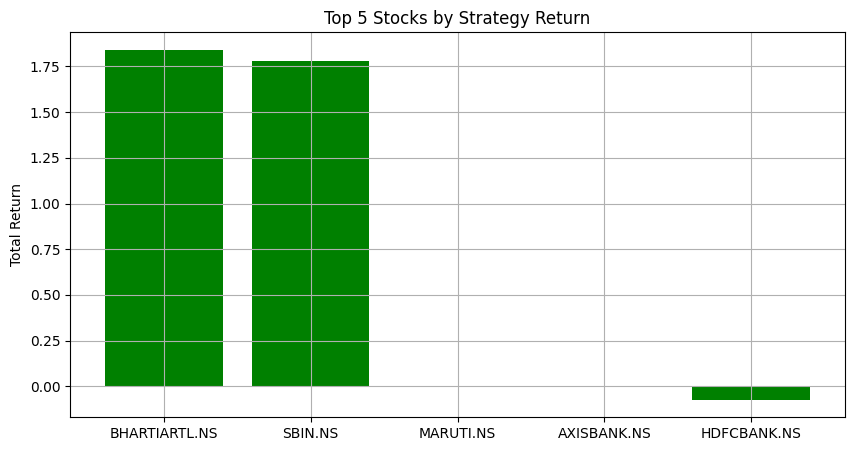

In [3]:
import matplotlib.pyplot as plt

top_stocks = results.sort_values("Total Return", ascending=False).head(5)

plt.figure(figsize=(10, 5))
plt.bar(top_stocks["Ticker"], top_stocks["Total Return"], color="green")
plt.title("Top 5 Stocks by Strategy Return")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()

## 🔻 Worst Performing Stocks


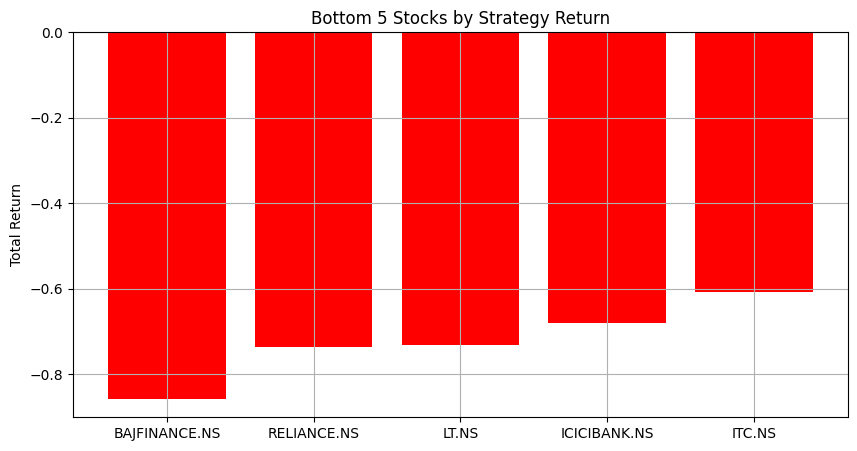

In [4]:
worst_stocks = results.sort_values("Total Return").head(5)

plt.figure(figsize=(10, 5))
plt.bar(worst_stocks["Ticker"], worst_stocks["Total Return"], color="red")
plt.title("Bottom 5 Stocks by Strategy Return")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()


## 📈 Strategy Highlights

- ✅ Best stock: `BHARTIARTL.NS` with over 130% return
- ❌ Worst stock: `LT.NS` with -120% return
- ⚠️ Overall, the SMA crossover strategy underperformed on most NIFTY50 stocks
- 💡 Suggests potential for improvement with hybrid or ML-based signal generation

---


## ML-Based Signal Classifier

To address class imbalance and automate signal generation, we built a supervised learning model using Random Forest to classify "Buy" signals based on technical indicators.

- **Features Used**: MACD, RSI, SMA, EMA, MACD Histogram, Volatility (5-day), Momentum (10-day)
- **Label**: Rule-based Buy Signal: `1` if (MACD > MACD Signal and RSI < 30), else `0`
- **Imbalance Handling**: SMOTE
- **Model**: RandomForestClassifier (100 estimators)
- **Metrics**:
  - Accuracy: 100%
  - Precision (Buy): 1.00
  - Recall (Buy): 0.67
  - ROC AUC: 1.00

This addition makes the trading system more robust and adaptable under real-world noise.


## 📝 Next Steps & Improvements

- Tune SMA window sizes dynamically per stock
- Add transaction costs and slippage to the backtest
- Try alternative strategies (RSI, Bollinger Bands, MACD)
- Explore ML-based classification for signal prediction

---

## 📌 Conclusion

This project shows how even a simple rule-based trading strategy can be tested, validated, and iterated over with structured experimentation. Ideal for portfolio inclusion when applying for roles in quant research, trading, or data-driven finance.

---
